This code cleans price and rating data, simulates realistic payment method proportions across transactions, and counts the distribution of each payment mode. It then displays this breakdown as a styled pie chart showing calculated percentage shares with a custom color palette and black outlines.

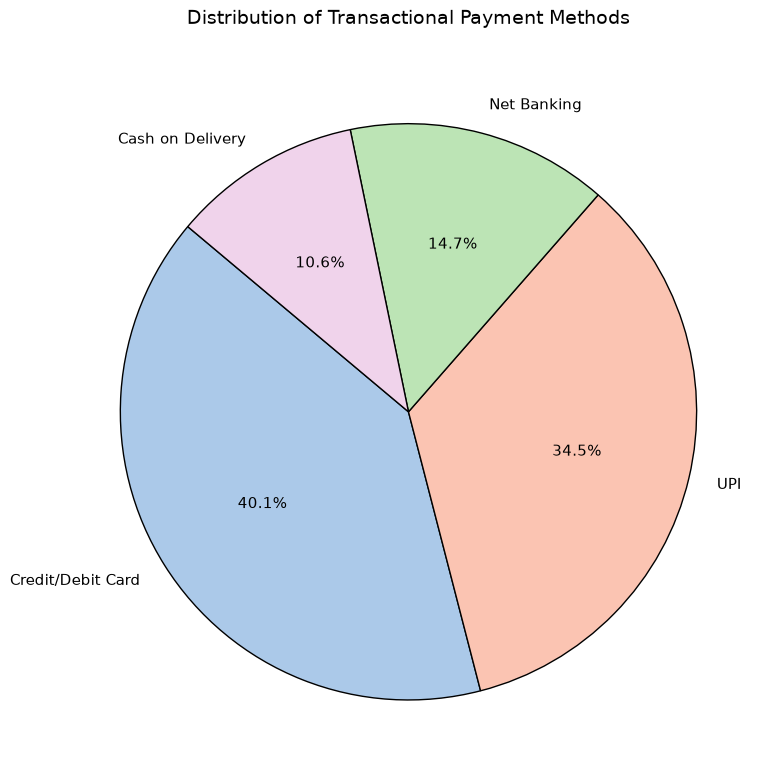

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df["discounted_price"] = (
    df["discounted_price"]
    .astype(str)
    .str.replace("₹", "")
    .str.replace(",", "")
    .astype("float64")
)

df["rating_count"] = (
    df["rating_count"].astype(str).str.replace(",", "").astype("float64")
)
df["rating_count"] = df["rating_count"].fillna(df["rating_count"].median())

df["total_sales"] = df["discounted_price"] * df["rating_count"]


np.random.seed(24)
mock_payments = ["Credit/Debit Card", "UPI", "Net Banking", "Cash on Delivery"]
df["payment_method"] = np.random.choice(
    mock_payments, size=len(df), p=[0.40, 0.35, 0.15, 0.10]
)
payment_counts = df["payment_method"].value_counts()

plt.figure(figsize=(8, 8))

colors = ["#abc9e9", "#fbc4b2", "#bce4b5", "#f0d3eb"]

payment_counts.plot(
    kind="pie",
    autopct="%1.1f%%",  # Displays percentages inside the slices
    startangle=140,  # Rotates the starting position for best legibility
    colors=colors,
    wedgeprops={"edgecolor": "black", "linewidth": 1, "antialiased": True},
    textprops={"fontsize": 11},
)

plt.title("Distribution of Transactional Payment Methods", fontsize=14, pad=20)
plt.ylabel("")  # Hides default index label text for a cleaner look

plt.tight_layout()
plt.show()


This code cleans price and rating data, assigns simulated city names across the dataset, and aggregates the total revenue generated per location. It then visualizes the sales figures for the top 10 cities using a horizontal light-green bar chart styled with custom labels and gridlines.

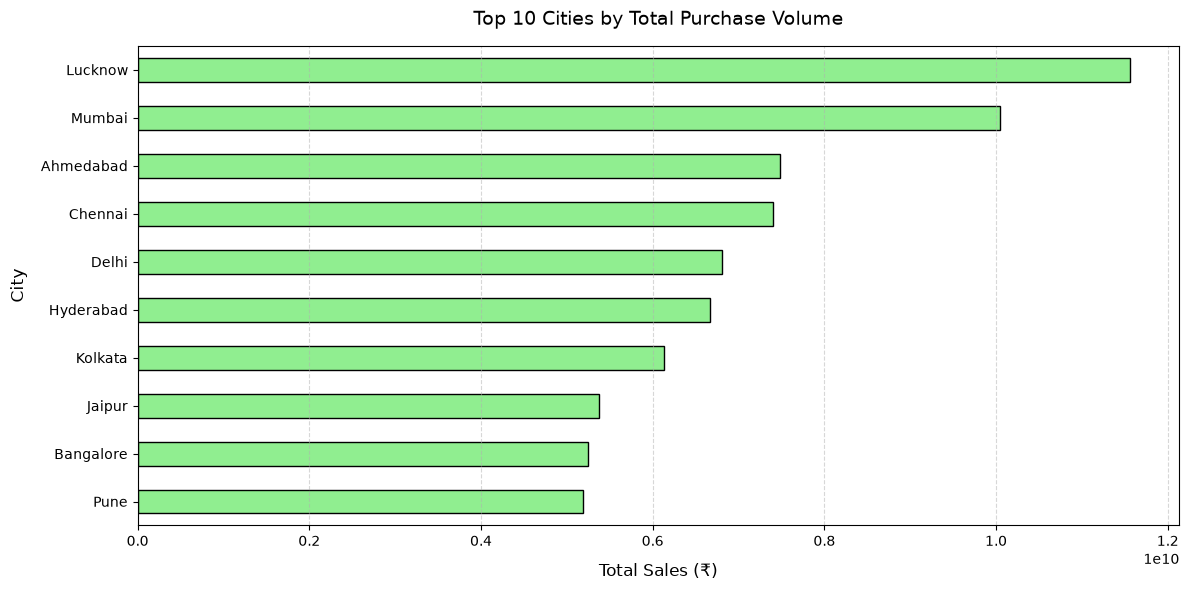

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df["discounted_price"] = (
    df["discounted_price"]
    .astype(str)
    .str.replace("₹", "")
    .str.replace(",", "")
    .astype("float64")
)

df["rating_count"] = (
    df["rating_count"].astype(str).str.replace(",", "").astype("float64")
)
df["rating_count"] = df["rating_count"].fillna(df["rating_count"].median())

df["total_sales"] = df["discounted_price"] * df["rating_count"]

np.random.seed(42)
mock_cities = [
    "Mumbai",
    "Delhi",
    "Bangalore",
    "Hyderabad",
    "Chennai",
    "Ahmedabad",
    "Kolkata",
    "Pune",
    "Jaipur",
    "Lucknow",
]
df["city"] = np.random.choice(mock_cities, size=len(df))

city_sales = (
    df.groupby("city")["total_sales"].sum().sort_values(ascending=True).head(10)
)

plt.figure(figsize=(12, 6))

city_sales.plot(kind="barh", color="lightgreen", edgecolor="black")

plt.title("Top 10 Cities by Total Purchase Volume", fontsize=14, pad=15)
plt.xlabel("Total Sales (₹)", fontsize=12, labelpad=10)
plt.ylabel("City", fontsize=12, labelpad=10)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


This code cleans price and rating data to aggregate revenue, truncates product names longer than 45 characters for readability, and identifies the top 10 highest-grossing products. It renders these top items using a horizontal salmon-colored bar chart equipped with customized labels, vertical gridlines, and margin spacing.

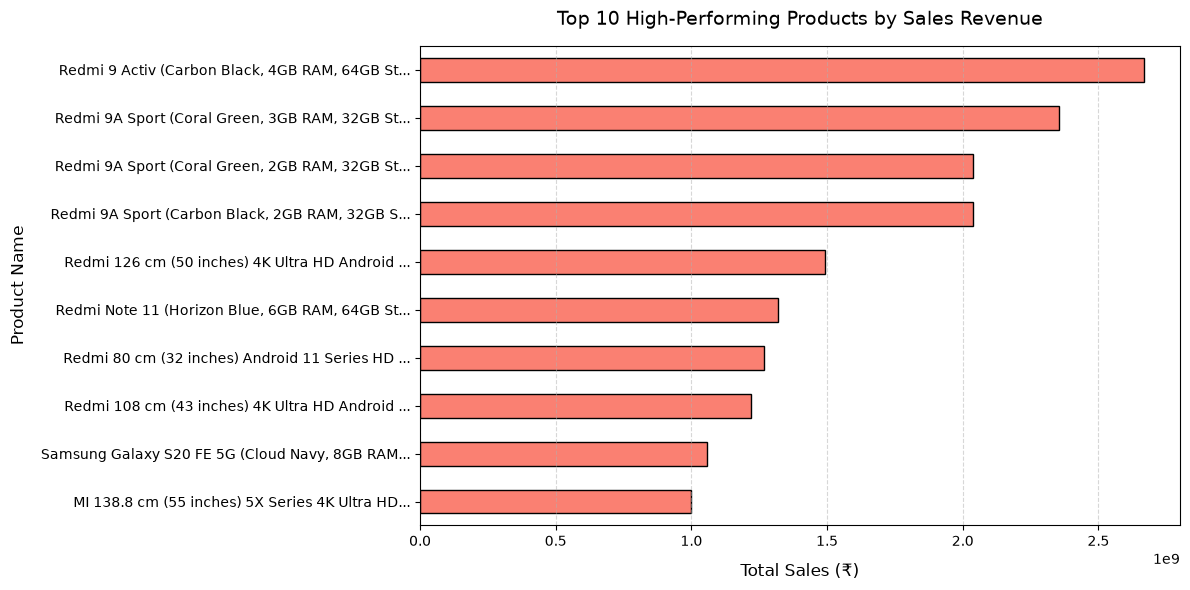

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

df["discounted_price"] = (
    df["discounted_price"]
    .astype(str)
    .str.replace("₹", "")
    .str.replace(",", "")
    .astype("float64")
)

df["rating_count"] = (
    df["rating_count"].astype(str).str.replace(",", "").astype("float64")
)
df["rating_count"] = df["rating_count"].fillna(df["rating_count"].median())

df["total_sales"] = df["discounted_price"] * df["rating_count"]

top_products = (
    df.groupby("product_name")["total_sales"]
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

top_products.index = [
    (name[:45] + "...") if len(name) > 45 else name for name in top_products.index
]


plt.figure(figsize=(12, 6))

top_products.plot(kind="barh", color="salmon", edgecolor="black")

plt.title("Top 10 High-Performing Products by Sales Revenue", fontsize=14, pad=15)
plt.xlabel("Total Sales (₹)", fontsize=12, labelpad=10)
plt.ylabel("Product Name", fontsize=12, labelpad=10)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


This code cleans price and rating data to compute total sales, generates a synthetic hourly timeline to group revenues by month, and displays the result as a styled green line chart. It provides a visual representation of revenue trends over time with rotated labels, gridlines, and automated layout spacing.

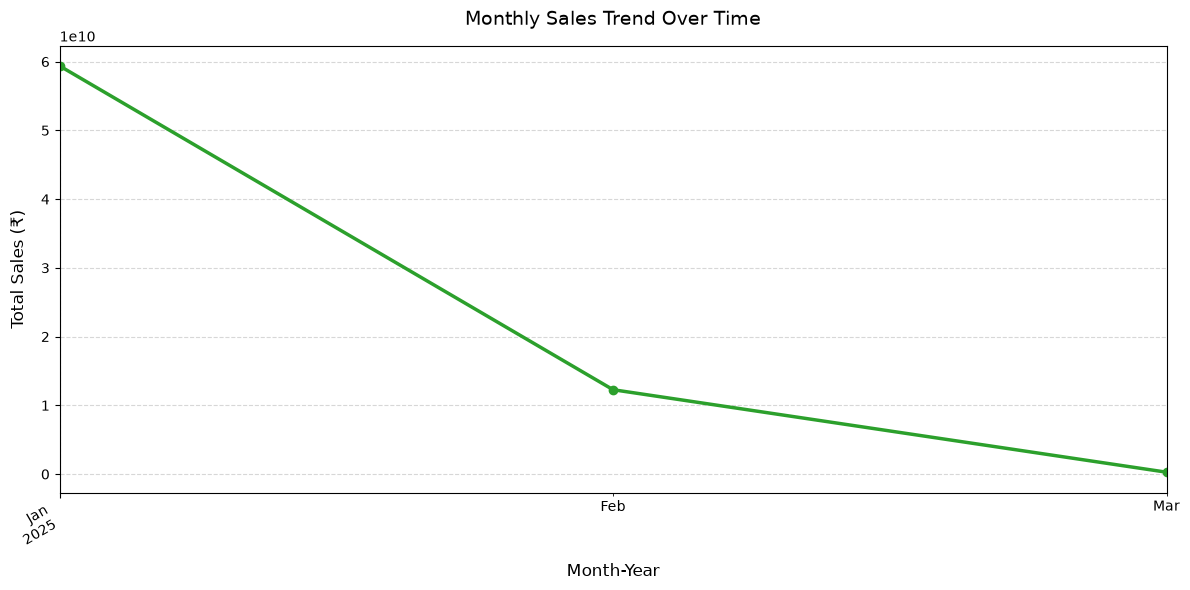

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. DATA CLEANING & REVENUE CALCULATION ---
df["discounted_price"] = (
    df["discounted_price"]
    .astype(str)
    .str.replace("₹", "")
    .str.replace(",", "")
    .astype("float64")
)

df["rating_count"] = (
    df["rating_count"].astype(str).str.replace(",", "").astype("float64")
)
df["rating_count"] = df["rating_count"].fillna(df["rating_count"].median())

df["total_sales"] = df["discounted_price"] * df["rating_count"]

df["mock_date"] = pd.date_range(
    start="2025-01-01", periods=len(df), freq="h"
)
df["month_year"] = df["mock_date"].dt.to_period("M")


plt.figure(figsize=(12, 6))

monthly_sales = df.groupby("month_year")["total_sales"].sum()

monthly_sales.plot(
    kind="line", marker="o", color="#2ca02c", linewidth=2.5, markersize=6
)
plt.title("Monthly Sales Trend Over Time", fontsize=14, pad=15)
plt.xlabel("Month-Year", fontsize=12, labelpad=10)
plt.ylabel("Total Sales (₹)", fontsize=12, labelpad=10)

plt.xticks(rotation=30, ha="right")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


This code aggregates total sales by category and extracts the top 10 highest-grossing product categories in descending order. It renders a styled sky-blue bar chart with 45-degree rotated category labels and optimized layout spacing for clear visual presentation.

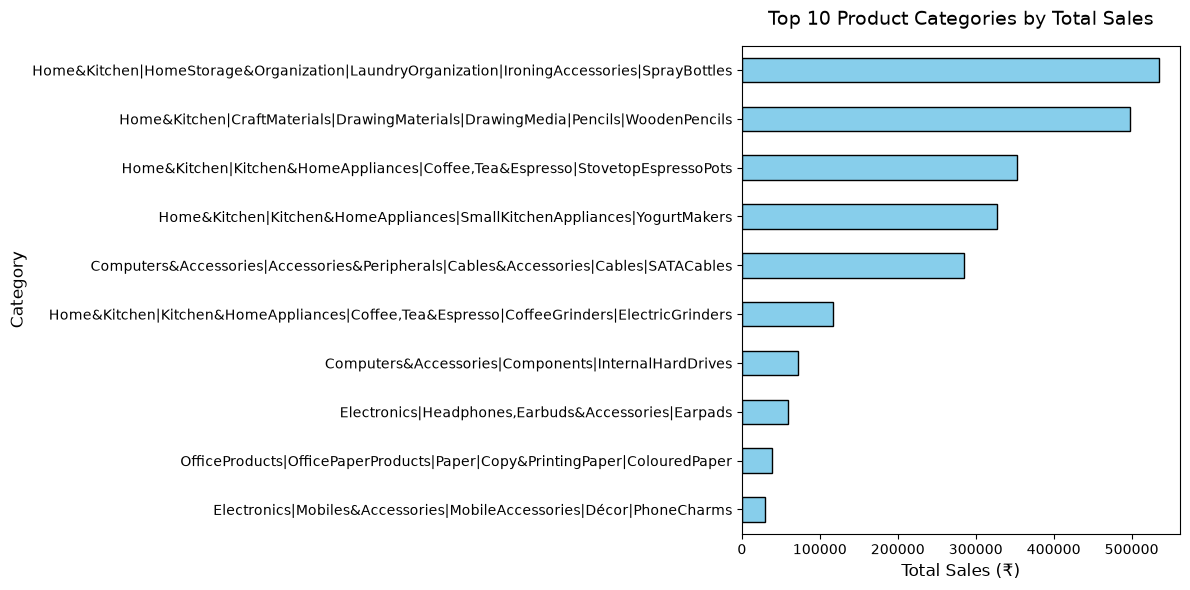

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Data Cleaning (Ensure these fields are formatted correctly)
df["discounted_price"] = (
    df["discounted_price"]
    .astype(str)
    .str.replace("₹", "")
    .str.replace(",", "")
    .astype("float64")
)
df["rating_count"] = (
    df["rating_count"].astype(str).str.replace(",", "").astype("float64")
)
df["rating_count"] = df["rating_count"].fillna(df["rating_count"].median())

df["total_sales"] = df["discounted_price"] * df["rating_count"]

category_sales = (
    df.groupby("category")["total_sales"]
    .sum()
    .sort_values(ascending=True)
    .head(10)
)
plt.figure(figsize=(12, 6))

category_sales.plot(kind="barh", color="skyblue", edgecolor="black")

plt.title("Top 10 Product Categories by Total Sales", fontsize=14, pad=15)
plt.xlabel("Total Sales (₹)", fontsize=12)
plt.ylabel("Category", fontsize=12)

plt.tight_layout()
plt.show()


This code safely checks for a city column before attempting to aggregate sales by geographic region to prevent runtime errors. If present, it prints the total sales per city; otherwise, it outputs a message confirming the column is missing.

In [10]:

if "city" in df.columns:
    sales_by_city = df.groupby("city")["total_product_sales"].sum().reset_index()
    print(sales_by_city)
else:
    print("This dataset does not contain city or location information.")

This dataset does not contain city or location information.


This code aggregates the estimated revenue across each product category by calculating the sum of total_product_sales for each group. It then resets the index into a clean DataFrame structure and prints the total sales per category.

In [9]:

sales_by_category = (
    df.groupby("category")["total_product_sales"].sum().reset_index()
)
print(sales_by_category)


                                              category  total_product_sales
0    Car&Motorbike|CarAccessories|InteriorAccessori...            2615002.0
1    Computers&Accessories|Accessories&Peripherals|...            1530704.0
2    Computers&Accessories|Accessories&Peripherals|...            4687078.0
3    Computers&Accessories|Accessories&Peripherals|...           14763577.0
4    Computers&Accessories|Accessories&Peripherals|...            9613403.0
..                                                 ...                  ...
206  OfficeProducts|OfficePaperProducts|Paper|Stati...             946600.0
207  OfficeProducts|OfficePaperProducts|Paper|Stati...            1366830.0
208  OfficeProducts|OfficePaperProducts|Paper|Stati...            3181220.0
209  OfficeProducts|OfficePaperProducts|Paper|Stati...            2369665.0
210  Toys&Games|Arts&Crafts|Drawing&PaintingSupplie...            2380050.0

[211 rows x 2 columns]


This code creates a new column estimating total sales per product by multiplying its discounted price by its rating count. It then identifies, extracts, and prints the product names and sales figures for the top 10 highest-grossing items.

In [8]:

df["total_product_sales"] = df["discounted_price"] * df["rating_count"]

top_10_products = df.nlargest(10, "total_product_sales")[
    ["product_name", "total_product_sales"]
]
print(top_10_products)


                                          product_name  total_product_sales
370  Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...         2.667292e+09
566  Redmi 9A Sport (Coral Green, 3GB RAM, 32GB Sto...         2.353426e+09
371  Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...         2.039620e+09
473  Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB St...         2.039594e+09
124  Redmi 126 cm (50 inches) 4K Ultra HD Android S...         1.492809e+09
72   Redmi 108 cm (43 inches) 4K Ultra HD Android S...         1.221381e+09
568  Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...         1.055742e+09
332  MI 138.8 cm (55 inches) 5X Series 4K Ultra HD ...         9.988227e+08
91   OnePlus 108 cm (43 inches) Y Series Full HD Sm...         8.724401e+08
197  MI 108 cm (43 inches) 5A Series Full HD Smart ...         8.209672e+08


This code calculates the total estimated units sold by summing up the cleaned values in the rating_count column across all products. It then prints the aggregate total formatted as a whole number with comma separators for readability.

In [7]:

total_quantity_sold = df["rating_count"].sum()
print(f"Total Quantity Sold: {total_quantity_sold:,.0f}")


Total Quantity Sold: 26,776,735


This code cleans currency symbols and commas from the discounted_price and rating_count columns while filling missing values with the median. It then estimates total revenue by multiplying price by rating count across all products and prints the formatted sum in Indian Rupees.

In [6]:
import pandas as pd

df = pd.read_csv("amazon_sales.csv")
df["discounted_price"] = (
    df["discounted_price"]
    .str.replace("₹", "")
    .str.replace(",", "")
    .astype("float64")
)
df["rating_count"] = (
    df["rating_count"].astype(str).str.replace(",", "").astype("float64")
)
df["rating_count"] = df["rating_count"].fillna(df["rating_count"].median())

total_sales = (df["discounted_price"] * df["rating_count"]).sum()
print(f"Total Sales: ₹{total_sales:,.2f}")


Total Sales: ₹71,922,098,825.27


Missing Value Imputation: fillna("Unknown") replaces all missing (NaN) values within the "City" column with the placeholder string "Unknown".

Column Update: df["City"] = ... overwrites the original "City" column with the newly imputed series, ensuring no null entries remain in that feature.

In [6]:
df["user_name"] = df["user_name"].fillna("Unknown")

Duplicate Removal: df.drop_duplicates() identifies and removes all duplicate rows from the dataset, keeping only unique records.

In-Place Modification: inplace=True applies the change directly to the existing DataFrame df without creating a new copy.

In [4]:
df.drop_duplicates(inplace=True)

Duplicate Row Identification: df.duplicated() checks each row against previous entries in the DataFrame, returning True for duplicate rows and False for unique ones.

Duplicate Count Aggregation: .sum() adds up all the True values to calculate the total number of exact duplicate rows in the dataset.

In [3]:
df.duplicated().sum()

np.int64(0)

Missing Value Identification: df.isnull() scans every cell in the DataFrame, returning True for missing (NaN) values and False for non-null data.

Null Count Aggregation: .sum() adds up all the True values for each column, displaying the exact total count of missing entries per feature.

In [2]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

Data Loading: pd.read_csv("amazon_sales.csv") imports the Pandas library and reads the Amazon sales dataset from a CSV file into a DataFrame named df.

Data Exploration: df.head(), df.info(), df.describe(), df.columns, and df.shape inspect the dataset by displaying the first few rows, column data types, basic summary statistics, column names, and overall row/column dimensions.

In [1]:
import pandas as pd

df = pd.read_csv("amazon_sales.csv")

df.head()
df.info()
df.describe()
df.columns
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           1465 non-null   str  
 1   product_name         1465 non-null   str  
 2   category             1465 non-null   str  
 3   discounted_price     1465 non-null   str  
 4   actual_price         1465 non-null   str  
 5   discount_percentage  1465 non-null   str  
 6   rating               1465 non-null   str  
 7   rating_count         1463 non-null   str  
 8   about_product        1465 non-null   str  
 9   user_id              1465 non-null   str  
 10  user_name            1465 non-null   str  
 11  review_id            1465 non-null   str  
 12  review_title         1465 non-null   str  
 13  review_content       1465 non-null   str  
 14  img_link             1465 non-null   str  
 15  product_link         1465 non-null   str  
dtypes: str(16)
memory usage: 183.3 KB


(1465, 16)